# Beijing Multi-Site Air Quality — Modelling Methodology Report

**Task.** Predict next-hour PM2.5 (`PM2_5_next_hour`) at 12 Beijing stations. Competition metric: **RMSE**.

**Constraint.** Train includes `current_PM2_5`. The test file does **not**. Persistence using true current PM2.5 is ineligible.

**Approach.** Interpolate short pollutant gaps within station (including a short train→test bridge), fill remaining holes with the same-hour city median then train-only means. Reconstruct current PM2.5 from test-available sensors (stage 1), including same-hour PM10/CO/NO2 at the other stations and inverse-distance neighbours. Stage 2 is a LightGBM seed-bag on that proxy plus PM10-centric lags, mixed 0.75/0.25 with a residual model around the proxy. Sep–Feb and high-PM rows are up-weighted. `year` is dropped (test includes 2017). Recursion was tried and **hurt** winter validation, so it is not in the submission.

Seed **42**. This notebook is the methodology report. Training code: `feature_engineering.py`, `train_and_submit.py`.


## 1. Setup

Python 3.11. Packages: pandas, numpy, scikit-learn, LightGBM, matplotlib, joblib, holidays (optional). See `requirements.txt`.

This notebook is the **methodology report**. It loads competition `data/train.csv` and `data/test.csv`. Gap-filling used for modelling is `feature_engineering.interpolate_then_mean_fill` (called from `train_and_submit.py`). It does **not** use `data/train_cleaned.csv`.

Artifacts:

- `submission.csv` — leaderboard prediction file (repo root and `outputs/`)
- `outputs/final_model_record.json` — model card
- `outputs/val_leaderboard.csv` — local validation scores
- fitted models under `outputs/`


In [1]:
%matplotlib inline
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from feature_engineering import TARGET, TIME_COL
from train_and_submit import (
    SEED,
    load_cleaned,
    run_validation,
    select_and_fit_final,
    rmse,
    postprocess,
)

ROOT = Path(".")
OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
print("seed", SEED)


/Users/yo/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


seed 42


## 2. Data and train/test protocol

- Train: 1 Mar 2013 – 31 Aug 2016, 360,954 hourly rows, 12 stations, target labelled.
- Test: 31 Aug 2016 23:00 – 28 Feb 2017, 51,063 rows, **no** `current_PM2_5`, **no** target.
- Test is entirely after train. Random row splits would leak the future. All validation below is chronological.

On train, `current_PM2_5` correlates ~0.96 with the next-hour target and PM10 ~0.84. After the protocol change, PM10, CO, NO2 and weather are the live signal for the whole test window.


In [2]:
train_raw, test_raw = load_cleaned()
print("train", train_raw.shape, train_raw[TIME_COL].min(), "→", train_raw[TIME_COL].max())
print("test ", test_raw.shape, test_raw[TIME_COL].min(), "→", test_raw[TIME_COL].max())
print("train columns extra vs test:", set(train_raw.columns) - set(test_raw.columns))
print("stations", sorted(train_raw["station"].unique()))
assert "current_PM2_5" in train_raw.columns
assert "current_PM2_5" not in test_raw.columns
assert TARGET in train_raw.columns and TARGET not in test_raw.columns


train (360954, 20) 2013-03-01 00:00:00 → 2016-08-31 22:00:00
test  (51063, 18) 2016-08-31 23:00:00 → 2017-02-28 22:00:00
train columns extra vs test: {'current_PM2_5', 'PM2_5_next_hour'}
stations ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']


## 3. Data cleaning and preprocessing

Implemented in `feature_engineering.interpolate_then_mean_fill`, which `train_and_submit.py` runs on `data/train.csv` and `data/test.csv`. `Data Cleaning.ipynb` is exploratory missing-value EDA; it is **not** a step in reproducing the prediction file.

1. Wind direction `wd`: missing → `"Missing"`.
2. Numeric pollutants and weather: **linear interpolate up to 6 hours** within each station, forward-fill up to 6 hours (test can ffill from the last train hours), then remaining holes get the **same-hour city median**, then **train-only column means**.
3. **`current_PM2_5` is never created or imputed on test.**
4. No row dropping. Target is complete in train.
5. No scaling (tree models).


## 4. Feature engineering

`feature_engineering.py`. Leakage-safe; true `current_PM2_5` is never a stage-2 feature.

**Stage 1 — current PM2.5 proxy**

LightGBM on PM10, CO, NO2, other gases, weather, RH / ventilation / wind u/v, heating season, city-wide PM10/CO/NO2, north vs south PM10, other-station mean/max, inverse-distance neighbours, station–month–hour climatology × PM10, PM10 lags, haze/inversion flags, station and `wd`. Out-of-fold on labelled rows.

**Stage 2**

- Predicted current PM2.5, lags and rolling means of that proxy
- Same-hour **PM10, CO, NO2 at every other station** (reshape of the competition table)
- PM10/CO/NO2 lags 1–24h, PM10 rolling mean/std
- Heating season (15 Nov–15 Mar), weekend, China holidays if `holidays` is installed
- Wind u/v, southerly flux, cyclic hour/month
- **`year` excluded** so 2017 test hours are not an unseen numeric split


## 5. Validation strategy

One chronological holdout. Stage 1 and climatology are fit on **dev only**.

| Window | Dev | Val | Role |
|---|---|---|---|
| Season-matched | before 2015-09-01 | Sep 2015 – Feb 2016 | **Primary / only selection window** — same months as test (autumn/winter, heating) |

Eligible baselines: last observed train PM2.5 held constant (LOCF), train-mean, stage-1 proxy used as next-hour. Oracle persistence $\hat y = $ true `current_PM2_5` is reported only as a ceiling and is **ineligible**.

The submitted blend is locked (0.75 seed-bag + 0.25 residual). Retraining always uses that recipe; the val table is for reporting, not a new search.


## 6. Models tested

| Model | Notes |
|---|---|
| LOCF / train-mean | Eligible baselines |
| Stage-1 proxy as next-hour | Reconstructed *current* PM2.5 used as if it persisted |
| LightGBM seed-bag | Seeds 42 and 2024, season × high-PM weights. No recursion. |
| LightGBM residual-on-proxy | Predicts next-hour minus stage-1 proxy, then adds the proxy back |
| Blend 0.75 bag + 0.25 residual | **Submitted.** Fixed mix, not tuned on a grid. |
| Recursion / XGB blends | Tried earlier; worse on winter val. |

Post-processing: clip to **[0, 999]**. No manual row edits.

Set `RETRAIN = True` to rebuild from scratch. If `outputs/val_leaderboard.csv` and `submission.csv` exist, `RETRAIN = False` loads them.


In [ ]:
RETRAIN = False  # True = re-run validation + final fit (slow)

board_path = OUT / "val_leaderboard.csv"
sub_path = ROOT / "submission.csv"
record_path = OUT / "final_model_record.json"

if RETRAIN or not board_path.exists() or not sub_path.exists():
    board, artifacts = run_validation(train_raw)
    board.to_csv(board_path, index=False)
    sub, record = select_and_fit_final(train_raw, test_raw, board)
else:
    board = pd.read_csv(board_path)
    sub = pd.read_csv(sub_path)
    record = json.loads(record_path.read_text())
    artifacts = None
    print("Loaded cached validation / submission. Set RETRAIN=True to rebuild.")

print(board.to_string(index=False))
print("\nSelected:", record.get("selected_label"), "season-matched RMSE", record.get("season_matched_val_rmse"))


Loaded cached validation / submission. Set RETRAIN=True to rebuild.
                         split                                model      rmse  best_iteration
season_matched_Sep2015_Feb2016                          LGB seed 42 25.774592           361.0
season_matched_Sep2015_Feb2016                        LGB seed 2024 25.782357           375.0
season_matched_Sep2015_Feb2016                    LightGBM seed-bag 25.730283           368.0
season_matched_Sep2015_Feb2016         LightGBM seed-bag + PM10 cap 25.738586             NaN
season_matched_Sep2015_Feb2016           LightGBM residual-on-proxy 25.827007           324.0
season_matched_Sep2015_Feb2016       Blend 0.75 bag + 0.25 residual 25.566988             NaN
season_matched_Sep2015_Feb2016      Oracle persistence (ineligible) 22.414253             NaN
season_matched_Sep2015_Feb2016 Stage-1 RMSE vs current (diagnostic) 22.445097             NaN
season_matched_Sep2015_Feb2016           Stage-1 proxy as next-hour 30.386694         

## 7. Validation results and model selection

Primary window: **Sep 2015 – Feb 2016** (same months as test).

**Selected: 0.75 LightGBM seed-bag + 0.25 residual-on-proxy** (800 trees each). Season-matched RMSE **25.57**.

| Model | Sep 2015–Feb 2016 RMSE |
|---|---:|
| Oracle persistence (ineligible) | 22.41 |
| Stage-1 RMSE vs true current (diagnostic) | 22.45 |
| **Blend 0.75 bag + 0.25 residual (submitted)** | **25.57** |
| LightGBM seed-bag | 25.73 |
| LightGBM residual-on-proxy | 25.83 |
| Previous seed-bag (182 features) | 26.07 |
| Stage-1 proxy as next-hour | 30.39 |

Richer stage-1 (neighbour IDW, extra lags, haze flags) is the main gain. Predicting stage-1 as a residual vs climatology *hurt* the proxy and was reverted. Recursion stays out.


In [4]:
primary = board[board["split"] == "season_matched_Sep2015_Feb2016"].copy()
eligible = primary[~primary["model"].str.contains("ineligible", case=False)]
eligible = eligible.sort_values("rmse")
display(eligible)

d = board[board["split"] == "season_matched_Sep2015_Feb2016"].sort_values("rmse")
colors = ["#c44" if "ineligible" in m.lower() else "#4c72b0" for m in d["model"]]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(d["model"], d["rmse"], color=colors)
ax.set_xlabel("RMSE (μg/m³)")
ax.set_title("Season-matched val RMSE (Sep 2015–Feb 2016)")
ax.invert_yaxis()
fig.tight_layout()
plt.show()


## 8. Ensembling and post-processing

Submitted file is a **fixed 0.75 / 0.25 mix** of the LightGBM seed-bag and a residual LightGBM around the stage-1 proxy. Mix weights were not grid-searched.

Clip predictions to `[0, 999]`. We do not force PM2.5 ≤ PM10.


In [5]:
print("submission rows", len(sub), "expected", len(test_raw))
print(sub["PM2_5_next_hour"].describe())
assert list(sub.columns) == ["id", "PM2_5_next_hour"]
assert len(sub) == len(test_raw)
assert sub["id"].tolist() == test_raw["id"].tolist()
assert sub["PM2_5_next_hour"].between(0, 999).all()
assert not sub.isna().any().any()

fig, ax = plt.subplots()
ax.hist(sub["PM2_5_next_hour"], bins=50, color="#4c72b0", edgecolor="white")
ax.set_xlabel("Predicted next-hour PM2.5 (μg/m³)")
ax.set_ylabel("Test rows")
ax.set_title("Submission prediction distribution")
plt.show()


submission rows 51063 expected 51063
count    51063.000000
mean        95.283126
std         99.450660
min          0.000000
25%         17.804185
50%         62.029164
75%        140.323927
max        722.409089
Name: PM2_5_next_hour, dtype: float64


## 9. Final model information

Written to `outputs/final_model_record.json` at fit time: selected label, season-matched RMSE, seeds, blend weights, LightGBM hyperparameters, and feature list.

Final fit uses **all** labelled train rows. Stage-1 OOF proxies on train; test uses a stage-1 model fit on all train. Stage-2 trees are **800** on the full train (val early-stopping was ~360–375). Ensemble: **0.75** mean of LightGBM seeds 42 and 2024, plus **0.25** residual LightGBM around the stage-1 proxy (`random_state=42`).


In [6]:
print(json.dumps({k: v for k, v in record.items() if k != "feature_cols"}, indent=2))
print("n_features", record.get("n_features"))


{
  "selected_label": "Blend 0.75 bag + 0.25 residual",
  "season_matched_val_rmse": 25.566988270740854,
  "n_estimators": 800,
  "seeds": [
    42,
    2024
  ],
  "learning_rate": 0.03,
  "seed": 42,
  "n_features": 189,
  "notes": "Richer stage-1 (IDW neighbours, extra lags, haze/inversion). Train-tail bridge into test interpolation. Direct current-PM2.5 proxy (not climatology residual). Submitted 0.75 LightGBM seed-bag + 0.25 residual-on-proxy. No recursive current-PM2.5. year dropped. Predictions clipped [0, 999].",
  "submission_rows": 51063,
  "submission_min": 0.0,
  "submission_max": 722.4090888396964,
  "submission_mean": 95.28312559642295,
  "submission_na": 0,
  "blend_weights": {
    "seed_bag": 0.75,
    "residual_on_proxy": 0.25
  },
  "hyperparameters": {
    "lightgbm_stage2": {
      "objective": "regression",
      "learning_rate": 0.03,
      "num_leaves": 63,
      "min_child_samples": 30,
      "subsample": 0.85,
      "colsample_bytree": 0.75,
      "reg_lambda":

## 9b. LightGBM feature importance (final model)

Split counts from `outputs/final_lgb_pass1.joblib` (the seed-42 member of the submitted bag). True `current_PM2_5` is absent; the proxy and PM10 dominate.


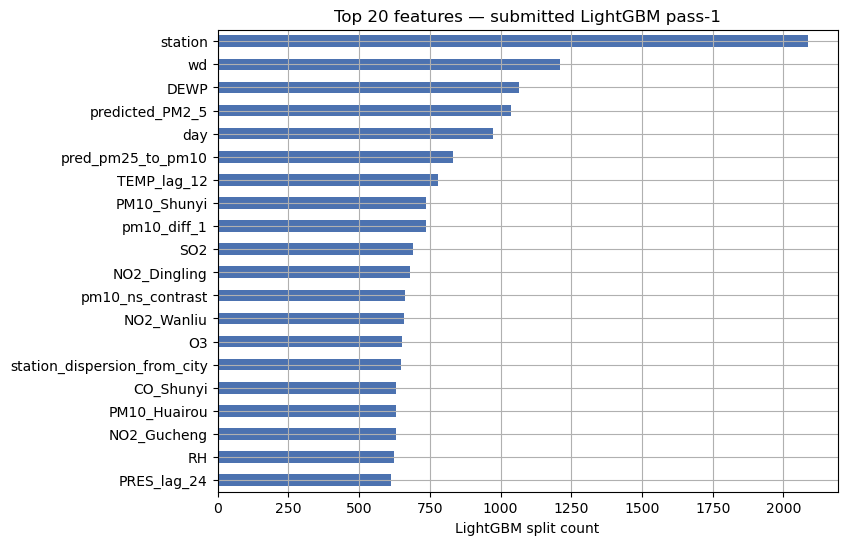

station                         2087
wd                              1209
DEWP                            1066
predicted_PM2_5                 1038
day                              974
pred_pm25_to_pm10                832
TEMP_lag_12                      780
PM10_Shunyi                      736
pm10_diff_1                      735
SO2                              689
NO2_Dingling                     680
pm10_ns_contrast                 663
NO2_Wanliu                       660
O3                               653
station_dispersion_from_city     649


In [ ]:
import joblib

lgb_final = joblib.load(OUT / "final_lgb_pass1.joblib")
feat_names = list(lgb_final.feature_name_)
imp = (
    pd.Series(lgb_final.feature_importances_, index=feat_names)
    .sort_values(ascending=True)
    .tail(20)
)
fig, ax = plt.subplots(figsize=(8, 6))
imp.plot.barh(ax=ax, color="#4c72b0")
ax.set_xlabel("LightGBM split count")
ax.set_title("Top 20 features — submitted LightGBM (seed 42 bag member)")
plt.show()
print(imp.sort_values(ascending=False).head(15).to_string())


## 10. Key observations and limitations

- Leaderboard RMSE for the first two-stage LightGBM was **25.69** (winter val 30.35). After spatial features the winter val was **26.07**. This file is **25.57** on the same window.
- Recursive last-prediction as current PM2.5 is theoretically the missing column, but on a six-month walk it was worse than ignoring it.
- Oracle persistence on interpolated train current PM2.5 is 22.41 on this winter window — still the ineligible ceiling. Stage-1 reconstructs current PM2.5 at 22.45 RMSE on that window.
- Gap-filling is reproducible interpolation/medians, not a physical interpolator (e.g. no CMAQ).
- No external air-quality feeds. Holidays use the public `holidays` China calendar if installed.


## 11. Required disclosure

- **External datasets:** none. Only the competition files `data/train.csv` and `data/test.csv`.
- **External code / public solutions:** none copied. Feature ideas (RH from TEMP/DEWP, wind u/v, heating season 15 Nov–15 Mar, lagged pollutants) are standard in Beijing PM2.5 literature, implemented here from scratch.
- **Pretrained models:** none. LightGBM is trained on this train set only. XGBoost and CatBoost were compared earlier and are **not** in the submitted file.
- **AI tools:** Cursor Grok 4.6 was used to draft and edit `02_Modelling.ipynb`, `feature_engineering.py`, `train_and_submit.py`, and `README.md`.
- **Manual modification of predictions:** none. `submission.csv` is the clipped model output (`[0, 999]`).
- **Additional information:** China public-holiday calendar via the `holidays` Python package (if installed); otherwise the holiday flag is 0. Station coordinates used for inverse-distance features are the published PRSA Beijing site locations (not an extra air-quality feed).


## 12. Reproduction

Full step-by-step instructions, seeds, and file list: **`README.md`**.

Short path:

1. Python 3.11, `pip install -r requirements.txt`.
2. Official `train.csv` and `test.csv` already in `data/`.
3. `python train_and_submit.py` writes `submission.csv`.
4. Or set `RETRAIN = True` in this notebook and run all cells.

Do **not** run `Data Cleaning.ipynb` as part of reproducing the prediction file.

Seed **42** (bag also uses **2024**). LightGBM `n_jobs=-1`; floating-point trees can differ slightly across machines.
